# **1. KNN-IRIS-1D**

**Step by step implementation**

## Step-by-step implementation

In [ ]:
import numpy as np
import pandas as pd

data = pd.read_csv('iris_1D.csv')
data

,Petal_Length,Label
0,1.4,0.0
1,1.0,0.0
2,1.5,0.0
3,3.1,1.0
4,3.8,1.0
5,4.1,1.0


In [ ]:
# 1. Data preparation

X = data['Petal_Length'].to_numpy()
print(X)
y = data['Label'].to_numpy()
print(y)

[1.4 1.  1.5 3.1 3.8 4.1]
[0. 0. 0. 1. 1. 1.]


In [ ]:
x_test = 2.4
print(x_test)

2.4


In [ ]:
# 2. Choose K = 3 and compute distance
k = 3

distances = np.sqrt((X - x_test) ** 2)
print(distances)

[1.  1.4 0.9 0.7 1.4 1.7]


In [ ]:
# 3. Take K = 3 Nearest neighbors

top_k = np.argsort(distances)
print(top_k)

k = 3
top_k = top_k[:k]
print(top_k)

[3 2 0 1 4 5]
[3 2 0]


In [ ]:
y

array([0., 0., 0., 1., 1., 1.])

In [ ]:
# get corresponding labels
values_top_k = y[top_k]
print(values_top_k)

[1. 0. 0.]


In [ ]:
# get mojority
num_zeros = (values_top_k == 0).sum()
num_ones = (values_top_k == 1).sum()

print(num_zeros)
print(num_ones)

2
1


In [ ]:
# get mojority 2
np.bincount(values_top_k.astype(int))

array([2, 1])

In [ ]:
majority_label = np.argmax(np.bincount(values_top_k.astype(int)))
print(majority_label)

0


## Way 1

In [ ]:
import numpy as np
import pandas as pd

data = pd.read_csv('iris_1D.csv')
x_data = data['Petal_Length'].to_numpy()
x_data = x_data.reshape(6, 1)

y_data = data['Label'].to_numpy()

# test input (unknown y)
x_test = [[2.4]]

print(x_data)
print(y_data)

[[1.4]
 [1. ]
 [1.5]
 [3.1]
 [3.8]
 [4.1]]
[0. 0. 0. 1. 1. 1.]


In [ ]:
from sklearn import neighbors, datasets
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(x_data, y_data)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = classifier.predict(x_test)
print(y_pred)

[0.]


## Way 2

In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_data, y_data)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
distances, indices = classifier.kneighbors(x_test)

In [ ]:
print("Distances:")
print(distances)

print("Indices:")
print(indices)

Distances:
[[0.7 0.9 1.  1.4 1.4 1.7]]
Indices:
[[3 2 0 1 4 5]]


In [ ]:
print("Neighbor x values:")
print(x_data[indices[0]])

print("Neighbor labels:")
print(y_data[indices[0]])

Neighbor x values:
[[3.1]
 [1.5]
 [1.4]
 [1. ]
 [3.8]
 [4.1]]
Neighbor labels:
[1. 0. 0. 0. 1. 1.]


In [ ]:
classifier.classes_

array([0., 1.])

In [ ]:
print("Prediction:")
print(classifier.predict(x_test))

Prediction:
[0.]


# **2. KNN-IRIS-2D**

## Step-by-step implementation

In [ ]:
import numpy as np
import pandas as pd

# Read csv
data = pd.read_csv('iris_2D.csv')

# Prepare data
X = data[["Petal_Length", "Petal_Width"]].to_numpy()
y = data["Label"].to_numpy()

In [ ]:
X = X.reshape(6, 2)

In [ ]:
x_test = np.array([2.4, 0.8]).reshape(1, 2)
x_test

array([[2.4, 0.8]])

In [ ]:
# Compute distance

distances = np.sqrt(((X - x_test) ** 2).sum(axis=1))
distances

array([1.16619038, 1.17046999, 1.11803399, 1.61245155, 2.37697286,
       1.3       ])

In [ ]:
# Choose k
k = 3

top_k = np.argsort(distances)
print(top_k)

top_k = top_k[:k]
print(top_k)

[2 0 1 5 3 4]
[2 0 1]


In [ ]:
values_top_k = y[top_k]
print(values_top_k)

[0. 0. 0.]


In [ ]:
# Get majority

y_pred = np.argmax(np.bincount(values_top_k.astype(int)))
print(y_pred)

0


## Way 1

In [ ]:
import numpy as np
import pandas as pd

x_data = data[['Petal_Length', 'Petal_Width']].to_numpy()
x_data = x_data.reshape(6, 2)

y_data = data['Label'].to_numpy()

x_test = np.array([2.4, 0.8])
x_test = x_test.reshape(1, 2)

In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(x_data, y_data)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = classifier.predict(x_test)
print(y_pred[0].astype(int))

0


## Way 2

In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_data, y_data)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
y_pred = classifier.kneighbors(x_test)
print(y_pred)

(array([[1.11803399, 1.16619038, 1.17046999, 1.3       , 1.61245155,
        2.37697286]]), array([[2, 0, 1, 5, 3, 4]]))


# **3. Scaling**

## **Why scaling**

***Khi dùng KNN, nếu dữ liệu chưa scaling thì feature có giá trị lớn hơn sẽ chi phối khoảng cách.***

### **IN CM**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets

data = pd.read_csv("/content/iris_2D.csv")

# get x
x_data = data[['Petal_Length', 'Petal_Width']].to_numpy()
x_data = x_data.reshape(6, 2)
print(x_data)

# get y
y_data = data['Label'].to_numpy()
print(y_data)

[[1.4 0.2]
 [1.3 0.4]
 [1.4 0.3]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]]
[0. 0. 0. 1. 1. 1.]


In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_data, y_data)

# unknown input
x_test = np.array([2.6, 0.7]).reshape(1, 2)
y_pred = classifier.kneighbors(x_test)
print(y_pred)

(array([[1.16619038, 1.26491106, 1.3       , 1.33416641, 1.43178211,
        2.21359436]]), array([[5, 2, 0, 1, 3, 4]]))


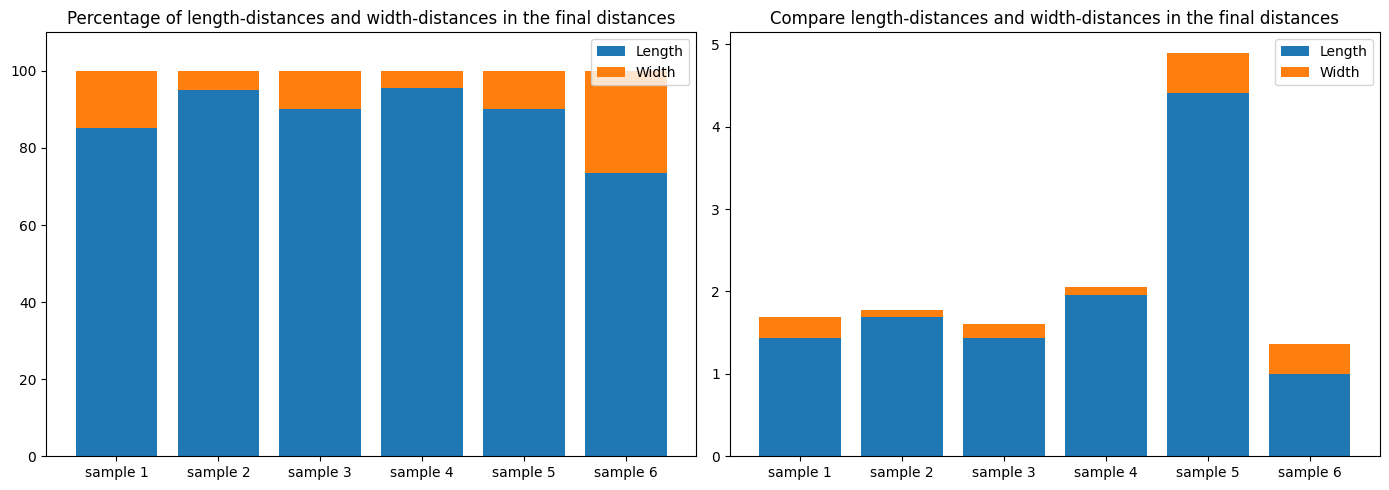

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_test = np.array([2.6, 0.7])

# Tính phần đóng góp của từng feature vào khoảng cách
length_distances = (x_data[:, 0] - x_test[0]) ** 2
width_distances = (x_data[:, 1] - x_test[1]) ** 2

# Tổng bình phương khoảng cách
final_distances = length_distances + width_distances

# Tính phần trăm đóng góp
length_percent = length_distances / final_distances * 100
width_percent = width_distances / final_distances * 100

# Tạo tên sample
samples = [f"sample {i}" for i in range(1, len(x_data) + 1)]

# Vẽ 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: phần trăm đóng góp
axes[0].bar(samples, length_percent, label="Length")
axes[0].bar(samples, width_percent, bottom=length_percent, label="Width")

axes[0].set_title("Percentage of length-distances and width-distances in the final distances")
axes[0].set_ylim(0, 110)
axes[0].legend()

# Biểu đồ 2: giá trị thật của từng phần khoảng cách
axes[1].bar(samples, length_distances, label="Length")
axes[1].bar(samples, width_distances, bottom=length_distances, label="Width")

axes[1].set_title("Compare length-distances and width-distances in the final distances")
axes[1].legend()

plt.tight_layout()
plt.show()

### IN MM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets
import pandas as pd

data = pd.read_csv('iris_2D_mm.csv')

# get x
x_data = data[['Petal_Length', 'Petal_Width']].to_numpy()
x_data = x_data.reshape(6, 2)
print(x_data)

# get y
y_data = data['Label'].to_numpy()
print(y_data)

[[ 1.4  2. ]
 [ 1.3  4. ]
 [ 1.4  3. ]
 [ 4.  10. ]
 [ 4.7 14. ]
 [ 3.6 13. ]]
[0. 0. 0. 1. 1. 1.]


In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_data, y_data)

# unknown input
x_test = [[2.6, 7.0]]
y_pred = classifier.kneighbors(x_test)
print(y_pred)

(array([[3.26955654, 3.31058907, 4.1761226 , 5.14198405, 6.08276253,
        7.30821456]]), array([[1, 3, 2, 0, 5, 4]]))


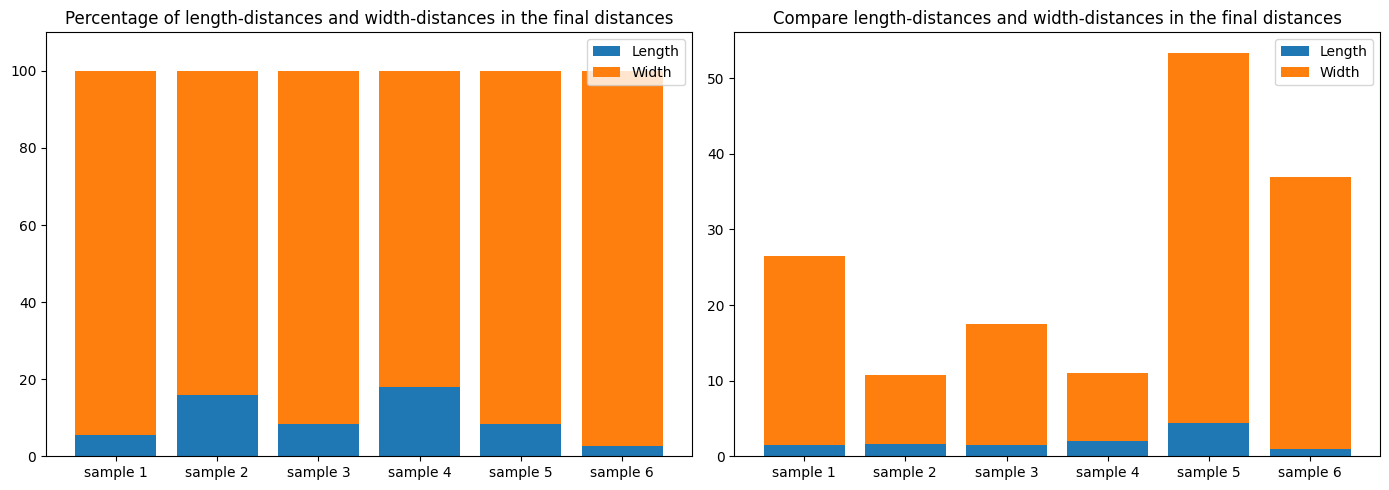

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_test = np.array([2.6, 7.0])

# Tính phần đóng góp của từng feature vào khoảng cách
length_distances = (x_data[:, 0] - x_test[0]) ** 2
width_distances = (x_data[:, 1] - x_test[1]) ** 2

# Tổng bình phương khoảng cách
final_distances = length_distances + width_distances

# Tính phần trăm đóng góp
length_percent = length_distances / final_distances * 100
width_percent = width_distances / final_distances * 100

# Tạo tên sample
samples = [f"sample {i}" for i in range(1, len(x_data) + 1)]

# Vẽ 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: phần trăm đóng góp
axes[0].bar(samples, length_percent, label="Length")
axes[0].bar(samples, width_percent, bottom=length_percent, label="Width")

axes[0].set_title("Percentage of length-distances and width-distances in the final distances")
axes[0].set_ylim(0, 110)
axes[0].legend()

# Biểu đồ 2: giá trị thật của từng phần khoảng cách
axes[1].bar(samples, length_distances, label="Length")
axes[1].bar(samples, width_distances, bottom=length_distances, label="Width")

axes[1].set_title("Compare length-distances and width-distances in the final distances")
axes[1].legend()

plt.tight_layout()
plt.show()

## **Using Scaling**

### IN CM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets
import pandas as pd
from sklearn.preprocessing import StandardScaler # Z-score

data = pd.read_csv('iris_2D.csv')

# get x
x_data = data[['Petal_Length', 'Petal_Width']].to_numpy()
x_data = x_data.reshape(6, 2)
print(x_data)

# get y
y_data = data['Label'].to_numpy()
print(y_data)

[[1.4 0.2]
 [1.3 0.4]
 [1.4 0.3]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]]
[0. 0. 0. 1. 1. 1.]


In [ ]:
# Chuẩn hóa
scaler = StandardScaler()
# Đọc thông tin từ x_data
scaler.fit(x_data)

# chuẩn hóa x = (x - mean) / std
x_data = scaler.transform(x_data)
print(x_data)

[[-0.94942533 -1.16756479]
 [-1.02063223 -0.7554831 ]
 [-0.94942533 -0.96152395]
 [ 0.90195406  0.48076197]
 [ 1.40040236  1.30492536]
 [ 0.61712646  1.09888451]]


In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_data, y_data)

# unknown input
x_test = [[2.6, 0.7]]
x_test = scaler.transform(x_test)
print(x_test)

y_pred = classifier.kneighbors(x_test)
print(y_pred)

[[2.6 0.7]]
(array([[1.34349142, 1.71214057, 2.02259643, 3.90223126, 3.91906647,
        4.01076282]]), array([[4, 3, 5, 1, 2, 0]]))


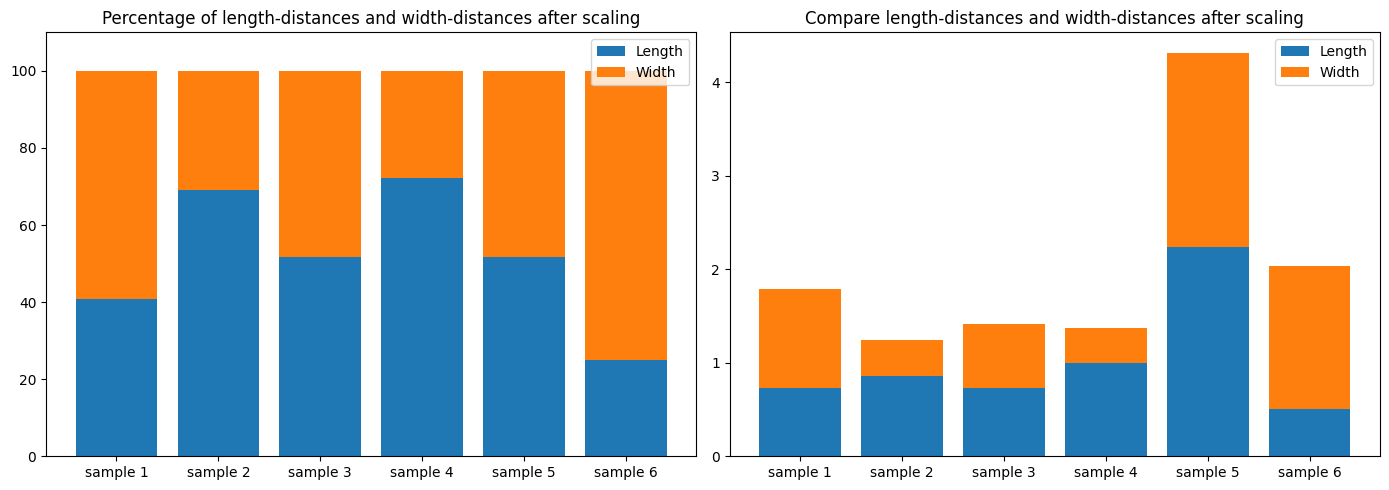

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dữ liệu gốc
x_data = data[['Petal_Length', 'Petal_Width']].to_numpy()
x_test = np.array([[2.6, 0.7]])

# Scaling
scaler = StandardScaler()
scaler.fit(x_data)

x_data_scaled = scaler.transform(x_data)
x_test_scaled = scaler.transform(x_test)

# Lấy x_test từ dạng [[...]] về dạng [...]
x_test_scaled = x_test_scaled[0]

# Tính phần đóng góp của từng feature vào khoảng cách
length_distances = (x_data_scaled[:, 0] - x_test_scaled[0]) ** 2
width_distances = (x_data_scaled[:, 1] - x_test_scaled[1]) ** 2

# Tổng bình phương khoảng cách
final_distances = length_distances + width_distances

# Tính phần trăm đóng góp
length_percent = length_distances / final_distances * 100
width_percent = width_distances / final_distances * 100

# Tên sample
samples = [f"sample {i}" for i in range(1, len(x_data_scaled) + 1)]

# Vẽ 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: phần trăm đóng góp
axes[0].bar(samples, length_percent, label="Length")
axes[0].bar(samples, width_percent, bottom=length_percent, label="Width")

axes[0].set_title("Percentage of length-distances and width-distances after scaling")
axes[0].set_ylim(0, 110)
axes[0].legend()

# Biểu đồ 2: giá trị thật của từng phần khoảng cách
axes[1].bar(samples, length_distances, label="Length")
axes[1].bar(samples, width_distances, bottom=length_distances, label="Width")

axes[1].set_title("Compare length-distances and width-distances after scaling")
axes[1].legend()

plt.tight_layout()
plt.show()

### IN MM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('iris_2D_mm.csv')

# get x
x_data = data[['Petal_Length', 'Petal_Width']].to_numpy()
x_data = x_data.reshape(6, 2)
print(x_data)

# get y
y_data = data['Label'].to_numpy()
print(y_data)

[[ 1.4  2. ]
 [ 1.3  4. ]
 [ 1.4  3. ]
 [ 4.  10. ]
 [ 4.7 14. ]
 [ 3.6 13. ]]
[0. 0. 0. 1. 1. 1.]


In [ ]:
scaler = StandardScaler()
scaler.fit(x_data)

x_data = scaler.transform(x_data)
print(x_data)

[[-0.94942533 -1.16756479]
 [-1.02063223 -0.7554831 ]
 [-0.94942533 -0.96152395]
 [ 0.90195406  0.48076197]
 [ 1.40040236  1.30492536]
 [ 0.61712646  1.09888451]]


In [ ]:
# get model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(x_data, y_data)

# unknown input
x_test = [[2.6, 7.0]]
x_test = scaler.transform(x_test)
print(x_test)

y_pred = classifier.kneighbors(x_test)
print(y_pred)

[[-0.09494253 -0.13736056]]
(array([[1.11309338, 1.17297838, 1.18717569, 1.33845493, 1.42665488,
        2.07755746]]), array([[1, 3, 2, 0, 5, 4]]))


# **4. BoW_KNN**

In [ ]:
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [ ]:
vectorizer = CountVectorizer()
corpus = ["góp gió gặt bão",
          "có làm mới có ăn",
          "đất lành chim đậu",
          "ăn cháo đá bát",
          "gậy ông đập lưng ông",
          "qua cầu rút ván"]
X = vectorizer.fit_transform(corpus)

In [ ]:
X = X.toarray()
print(X)

[[0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 2 0 0 0 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0]]


In [ ]:
x_test = vectorizer.transform(['không làm cạp đất mà ăn']).toarray()
x_test

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0]])

In [ ]:
y_data = np.array([1, 1, 1, 0, 0, 0])
y_data

array([1, 1, 1, 0, 0, 0])

## Step-by-Step

In [ ]:
# compute distance
distance = np.sqrt(((X - x_test) ** 2).sum(axis = 1))
print(distance)

[2.64575131 2.44948974 2.23606798 2.23606798 3.16227766 2.64575131]


In [ ]:
# get the top k
k = 3
top_k = np.argsort(distance)[:k]
print(top_k)

[3 2 1]


## sklearn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(X, y_data)

y_pred = classifier.kneighbors(x_test)
print(y_pred)

(array([[2.23606798, 2.23606798, 2.44948974]]), array([[3, 2, 1]]))


# **5. KNN_text_cls_tf-idf**

In [ ]:
# !pip install scikit-learn==1.3.0 numpy==1.25.2

In [ ]:
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
import numpy as np

In [ ]:
corpus = [
    "góp gió gặt bão",
    "có làm mới có ăn",
    "đất lành chim đậu",
    "ăn cháo đá bát",
    "gậy ông đập lưng ông",
    "qua cầu rút ván"
]

n_doc = len(corpus)

labels = [1, 1, 1, 0, 0, 0] # 1: positive - 0: negative

cate_2_label = {
    "positive": 1,
    "negative": 0
}

In [ ]:
def label_to_cate(labels):
    key_list = list(cate_2_label.keys())
    val_list = list(cate_2_label.values())

    position = [val_list.index(label) for label in labels]
    return np.array(key_list)[position]

In [ ]:
X = np.array(corpus)
print(X)
y = np.array(labels)
print(y)

['góp gió gặt bão' 'có làm mới có ăn' 'đất lành chim đậu' 'ăn cháo đá bát'
 'gậy ông đập lưng ông' 'qua cầu rút ván']
[1 1 1 0 0 0]


## Convert text to vector by using TF-IDF transform

In [ ]:
def calculate_tfidf(X_vectorized):
    tf = np.log(X_vectorized + 1)
    df = np.sum(X_vectorized, axis = 0)
    idf = np.log((n_doc + 1)/(df + 1)) + 1
    tfidf = tf * idf

    return idf, tf, tfidf

In [ ]:
# Chuẩn hóa đưa về vector đơn vị có độ dài là 1
def compute_norm(tfidf_vec):
    norm = np.linalg.norm(tfidf_vec, axis = 1)
    n_doc = tfidf_vec.shape[0]
    for i in range(n_doc):
        tfidf_vec[i] /= norm[i]

    return tfidf_vec

In [ ]:
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X).toarray()
print("Vocab: ", vectorizer.get_feature_names_out())

Vocab:  ['bát' 'bão' 'chim' 'cháo' 'có' 'cầu' 'gió' 'góp' 'gậy' 'gặt' 'làm' 'lành'
 'lưng' 'mới' 'qua' 'rút' 'ván' 'ông' 'ăn' 'đá' 'đất' 'đập' 'đậu']


In [ ]:
X_idf, x_tf, X_tfidf = calculate_tfidf(X_vectorized)

In [ ]:
print("idf is: ", X_idf)
print("tf is: ", x_tf)
print("tf-idf is: ",X_tfidf)

idf is:  [2.25276297 2.25276297 2.25276297 2.25276297 1.84729786 2.25276297
 2.25276297 2.25276297 2.25276297 2.25276297 2.25276297 2.25276297
 2.25276297 2.25276297 2.25276297 2.25276297 2.25276297 1.84729786
 1.84729786 2.25276297 2.25276297 2.25276297 2.25276297]
tf is:  [[0.         0.69314718 0.         0.         0.         0.
  0.69314718 0.69314718 0.         0.69314718 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         1.09861229 0.
  0.         0.         0.         0.         0.69314718 0.
  0.         0.69314718 0.         0.         0.         0.
  0.69314718 0.         0.         0.         0.        ]
 [0.         0.         0.69314718 0.         0.         0.
  0.         0.         0.         0.         0.         0.69314718
  0.         0.         0.         0.         0.         0.
  0.         0.         0.69314718 0.         0.69314718]
 [0

## Normlize TF-IDF values by L2 norm

In [ ]:
compute_norm(X_tfidf)

array([[0.        , 0.5       , 0.        , 0.        , 0.        ,
        0.        , 0.5       , 0.5       , 0.        , 0.5       ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.62232376,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.47882405, 0.        , 0.        , 0.47882405, 0.        ,
        0.        , 0.        , 0.        , 0.39264257, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.5       , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.5       , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.5       , 0.        , 0.5       ],
       [0.52182349, 0.        , 0.        , 0.521

## Train model KNN with 1 neighbor

In [ ]:
knn_cls = KNeighborsClassifier(n_neighbors=3)
knn_cls.fit(X_tfidf, y)
preds = knn_cls.predict(X_tfidf)
print(preds)

[1 0 1 1 1 1]


## Using pipeline of sklearn

In [ ]:
text_clf_model = Pipeline([('vect', CountVectorizer()),
                            ('tfidf', TfidfTransformer()),
                            ('clf', KNeighborsClassifier(n_neighbors=1)),
                        ])

text_clf_model.fit(X, y)

preds = text_clf_model.predict(X)
print(preds)

[1 1 1 0 0 0]


### Inference

In [ ]:
test_text = np.array(["không làm cạp đất mà ăn"])
test_vec = vectorizer.transform(test_text).toarray()

In [ ]:
test_tf = np.log(test_vec + 1)
test_tfidf = test_tf * X_idf

In [ ]:
compute_norm(test_tfidf)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.61171251, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.50161301, 0.        ,
        0.61171251, 0.        , 0.        ]])

In [ ]:
pred = knn_cls.predict(test_tfidf)

print(label_to_cate(pred))

['positive']


# **5. KNN_regression**

## sklearn

In [7]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('/content/Salary_Data_simple.csv')
df

,Experience,Salary
0,1.0,0.0
1,1.5,0.0
2,2.0,0.0
3,2.5,0.0
4,3.0,60.0
5,3.5,64.0
6,4.0,55.0
7,4.5,61.0
8,5.0,66.0
9,5.5,83.0


In [8]:
x_data = df.iloc[:, :-1].to_numpy()
y_data = df.iloc[:, -1:].to_numpy()
print(x_data)
print(y_data)

[[1. ]
 [1.5]
 [2. ]
 [2.5]
 [3. ]
 [3.5]
 [4. ]
 [4.5]
 [5. ]
 [5.5]
 [6. ]
 [6.5]
 [7. ]
 [7.5]]
[[  0.]
 [  0.]
 [  0.]
 [  0.]
 [ 60.]
 [ 64.]
 [ 55.]
 [ 61.]
 [ 66.]
 [ 83.]
 [ 93.]
 [ 91.]
 [ 98.]
 [101.]]


In [9]:
# Get model
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(x_data, y_data)

x_test = [[5.3]]
y_pred = knn.predict(x_test)
print(y_pred)

[[80.66666667]]


## step by step implementation

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Salary_Data_simple.csv')

# get data
x_data = df.iloc[:, :-1].to_numpy()
y_data = df.iloc[:, -1:].to_numpy()

# define the test data point
x_test = np.array([5.3])

# compute distances between x_test and all points in x_data
distances = np.sqrt(np.sum((x_data - x_test) ** 2, axis = 1))

# Find indices of k nearest neighbors
k = 3
nearest_neighbor_indices = np.argsort(distances)[:k]

# Get the corresponding y values
nearest_neighbor_salaries = y_data[nearest_neighbor_indices]

# Calculate the average salary of the k nearest neighbors
average_salary = np.mean(nearest_neighbor_salaries)

# Calculate the mean of nearestt neighbors salaries
predicted_salary = np.mean(nearest_neighbor_salaries)
print(predicted_salary)

80.66666666666667
